# Hotel Booking Cancellation Prediction

## 1. Project Summary & Problem Statement

**Project Overview:**
Hotel cancellations create significant revenue and operational planning challenges such as
unsold rooms, wasted staffing, and inaccurate demand forecasts. This project builds a
machine learning model to predict whether a hotel booking will be canceled, using
booking, customer, and stay characteristics available at the time of reservation.

**Dataset Description:**
- **Source:** Hotel Booking Demand dataset (`hotel_bookings.csv`)
- **Size:** 119,390 bookings, 32 raw variables
- **Key variables:** hotel type, lead time, arrival date, stay length, number of guests,
  deposit type, market segment, customer type, ADR (average daily rate), special requests,
  and the target variable `is_canceled`

### Setup
Install and import the libraries needed for data handling, visualization, and modeling.

In [ ]:
#pip install plotly
#pip install xgboost
#pip install gradio

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import yeojohnson
import math
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import os
import gradio as gr


## 2. Data Cleaning & Pre-processing

### 2.1 Data Inspection
Before cleaning, we first inspect the raw dataset structure, data types, and basic statistics.

In [ ]:
df = pd.read_csv('hotel_bookings.csv')

print("Shape:", df.shape)
df.head()


Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df.describe(include='all')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


In [ ]:
df.describe(include=['int64', 'float64'])

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
df.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
display(df.describe(include='all').T)

Rows: 119390
Columns: 32

Data types:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       obj

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


In [ ]:
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage": df.isnull().mean() * 100
})

print(missing[missing["Missing"] > 0].sort_values("Percentage", ascending=False))

          Missing  Percentage
company    112593   94.306893
agent       16340   13.686238
country       488    0.408744
children        4    0.003350


In [ ]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 31994


In [ ]:
print(df["is_canceled"].value_counts())
print(df["is_canceled"].value_counts(normalize=True).rename("proportion"))

is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64


### Initial observations

- The dataset contains **119,390 bookings and 32 variables**.
- `company` has a very large amount of missing data and will be removed.
- `agent`, `country`, and `children` need appropriate missing-value treatment.
- Exact duplicates must be removed before analysis.
- The target is moderately imbalanced, so accuracy should not be the only model metric.


### 2.2 Remove Exact Duplicates

In [ ]:
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

print("\nCancellation rate after removing duplicates:")
print(df["is_canceled"].value_counts(normalize=True).rename("proportion"))

Shape after removing duplicates: (87396, 32)
Remaining duplicates: 0

Cancellation rate after removing duplicates:
is_canceled
0    0.725102
1    0.274898
Name: proportion, dtype: float64


### Explanation for Duplicate Removal

Exact duplicate rows represent identical booking records. Removing them is crucial to ensure that our analysis and model training are based on unique observations, preventing data leakage and biased results. These duplicates often arise from data entry errors or how data was collected, and they do not add unique information for predicting cancellations.

### 2.3 Handle missing values

In [ ]:
print("Missing before treatment:")
print(df[["company", "agent", "country", "children"]].isnull().sum())

Missing before treatment:
company     82137
agent       12193
country       452
children        4
dtype: int64



- `company`: drop because more than 90% of values are missing.
- `children`: fill with 0 because only a few records are missing.
- `country`: use `"Unknown"` so we do not lose the bookings.
- `agent`: use `"Unknown"` and later treat it as categorical, not as a continuous number.

In [ ]:
df = df.drop(columns=["company"])

# Fill remaining missing values
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna("Unknown")

print("\nMissing after treatment:")
print(df.isnull().sum().sort_values(ascending=False).head(5))


Missing after treatment:
hotel                 0
is_canceled           0
lead_time             0
arrival_date_year     0
arrival_date_month    0
dtype: int64


### 2.4 Check suspicious records

We check for:
- Bookings with zero guests
- Bookings with zero nights
- Negative ADR

These records are not useful for a normal hotel-booking cancellation model.

In [ ]:
df["total_guests"] = df["adults"] + df["children"] + df["babies"]

df["total_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

print("Bookings with zero guests:", (df["total_guests"] == 0).sum())
print("Bookings with zero nights:", (df["total_nights"] == 0).sum())
print("Bookings with negative ADR:", (df["adr"] < 0).sum())

df.loc[df["adr"] < 0, ["hotel", "adr", "is_canceled"]]

Bookings with zero guests: 166
Bookings with zero nights: 651
Bookings with negative ADR: 1


,hotel,adr,is_canceled
14969,Resort Hotel,-6.38,0


### 2.5 Outlier Detection


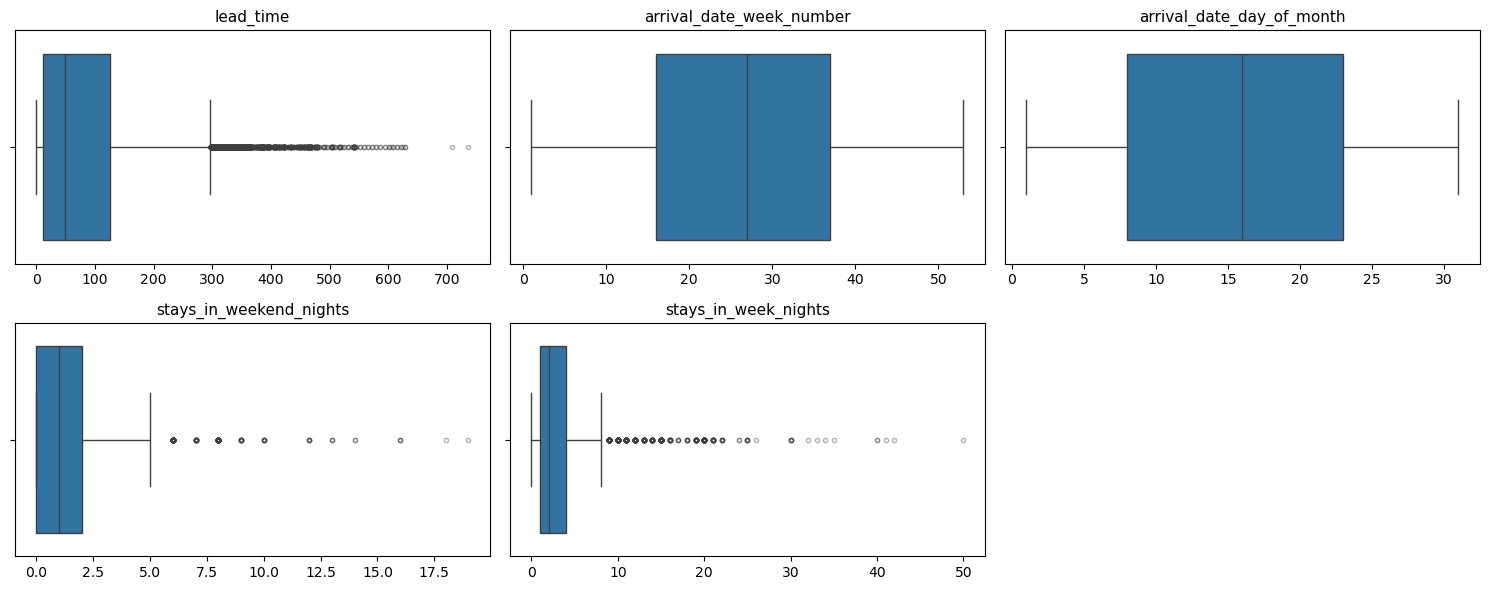

In [ ]:
selected_cols = ['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month',
                  'stays_in_weekend_nights', 'stays_in_week_nights']

n_cols = 3
n_rows = -(-len(selected_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3*n_rows))
axes = axes.flatten()

for ax, col in zip(axes, selected_cols):
    sns.boxplot(x=df[col], ax=ax, flierprops={'markersize': 3, 'alpha': 0.4})
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')

for ax in axes[len(selected_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
def count_outliers(series):
    Q1 = pd.Series(series).quantile(0.25)
    Q3 = pd.Series(series).quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return ((series < lower) | (series > upper)).sum()

def plot_transformations(df, col):

    log_data = np.log1p(df[col])
    sqrt_data = np.sqrt(df[col])
    yeo_data, _ = yeojohnson(df[col])

    fig, axes = plt.subplots(1, 4, figsize=(20,5))

    data_list = [
        (df[col], "Original", "blue"),
        (log_data, "Log", "green"),
        (sqrt_data, "Sqrt", "orange"),
        (yeo_data, "Yeo-Johnson", "red")
    ]

    for ax, (data, title, color) in zip(axes, data_list):
        sns.histplot(data, kde=True, ax=ax, color=color)

        ax.set_title(
            f"{title}\nOutliers = {count_outliers(pd.Series(data))}"
        )

    plt.suptitle(f"Transformations for {col}")
    plt.tight_layout()
    plt.show()

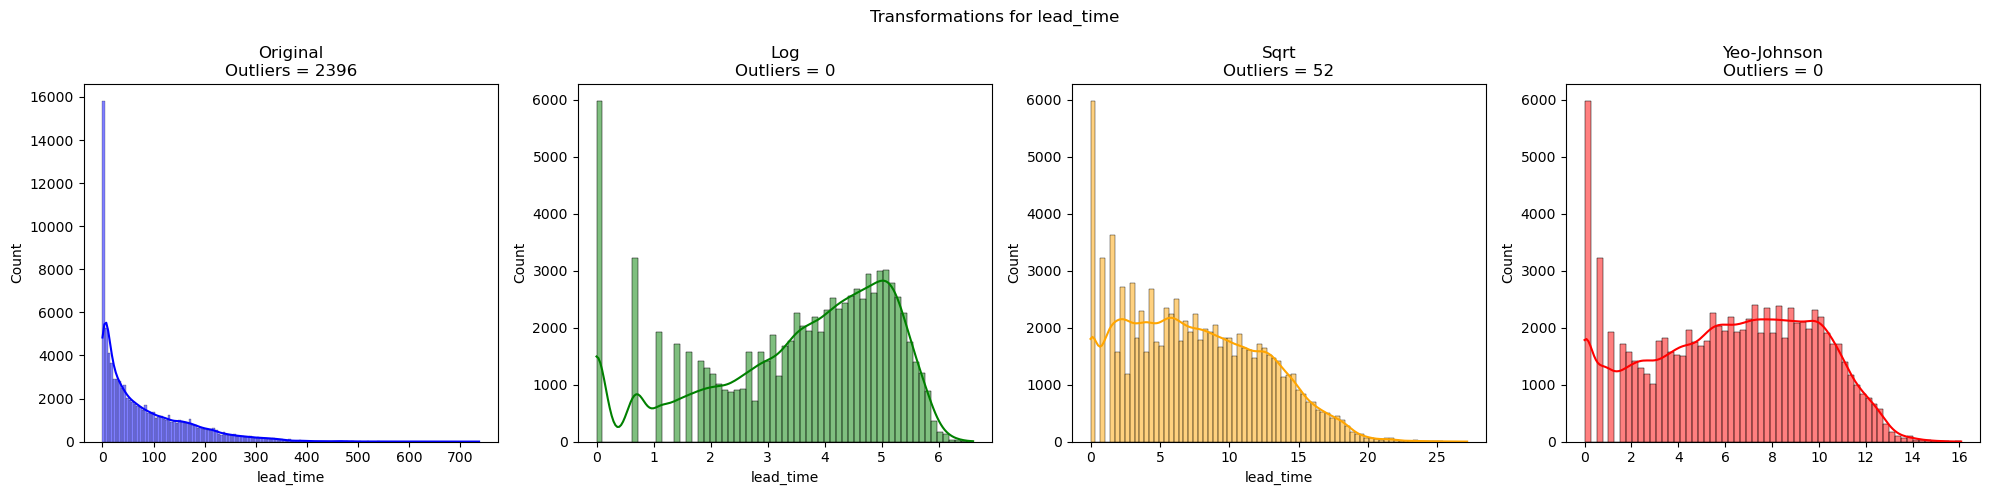

c:\Users\Nardy\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Nardy\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


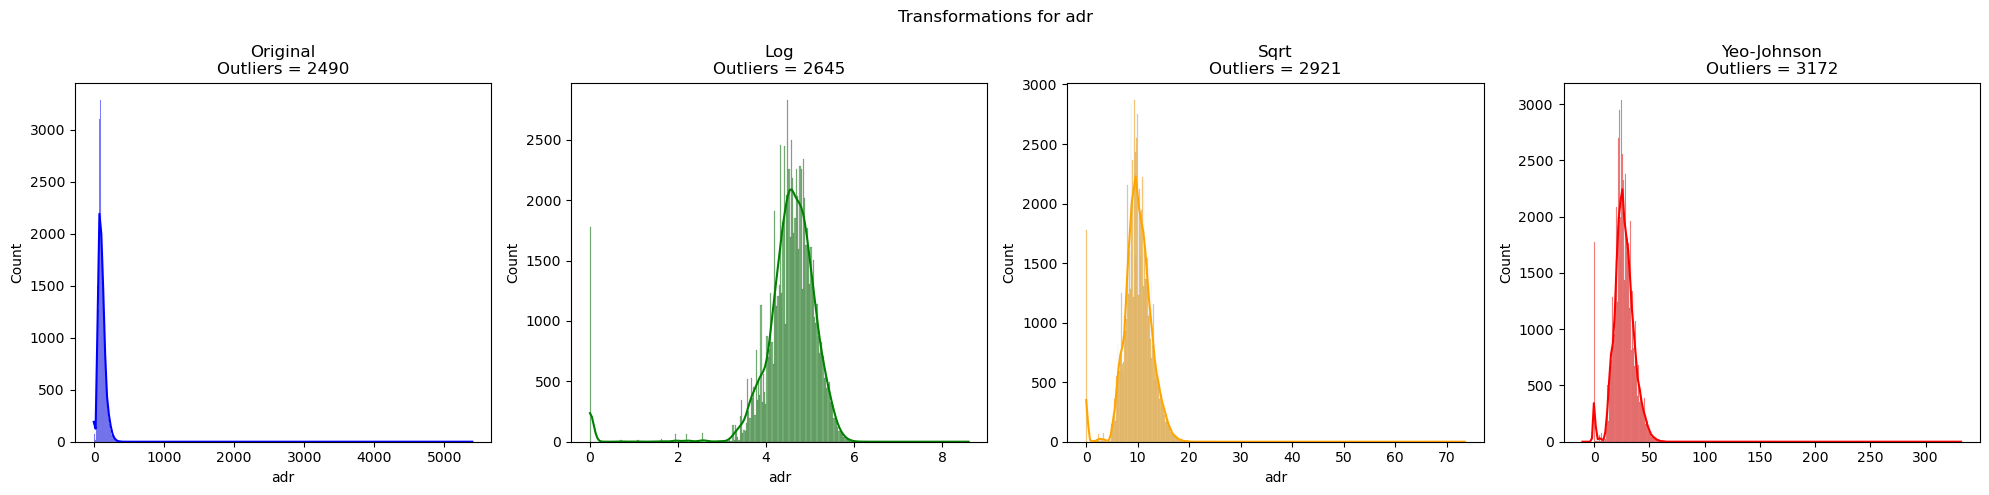

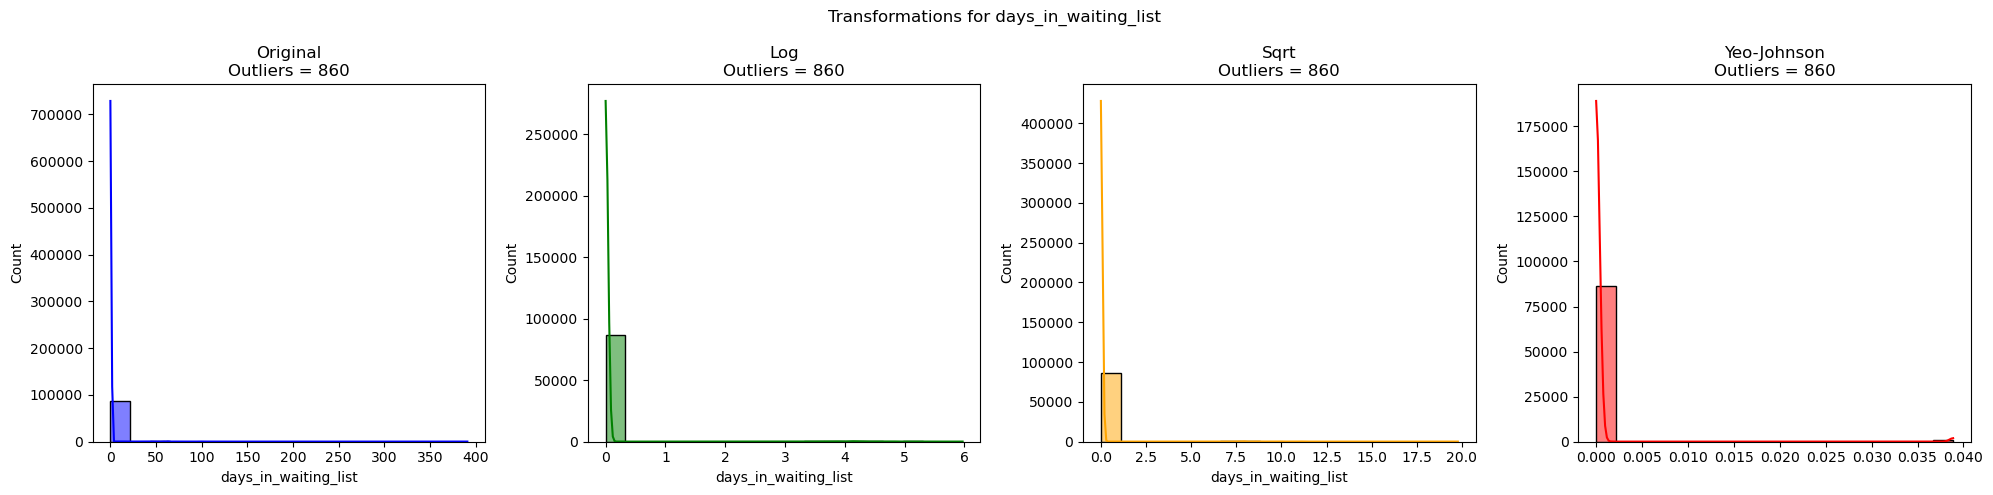

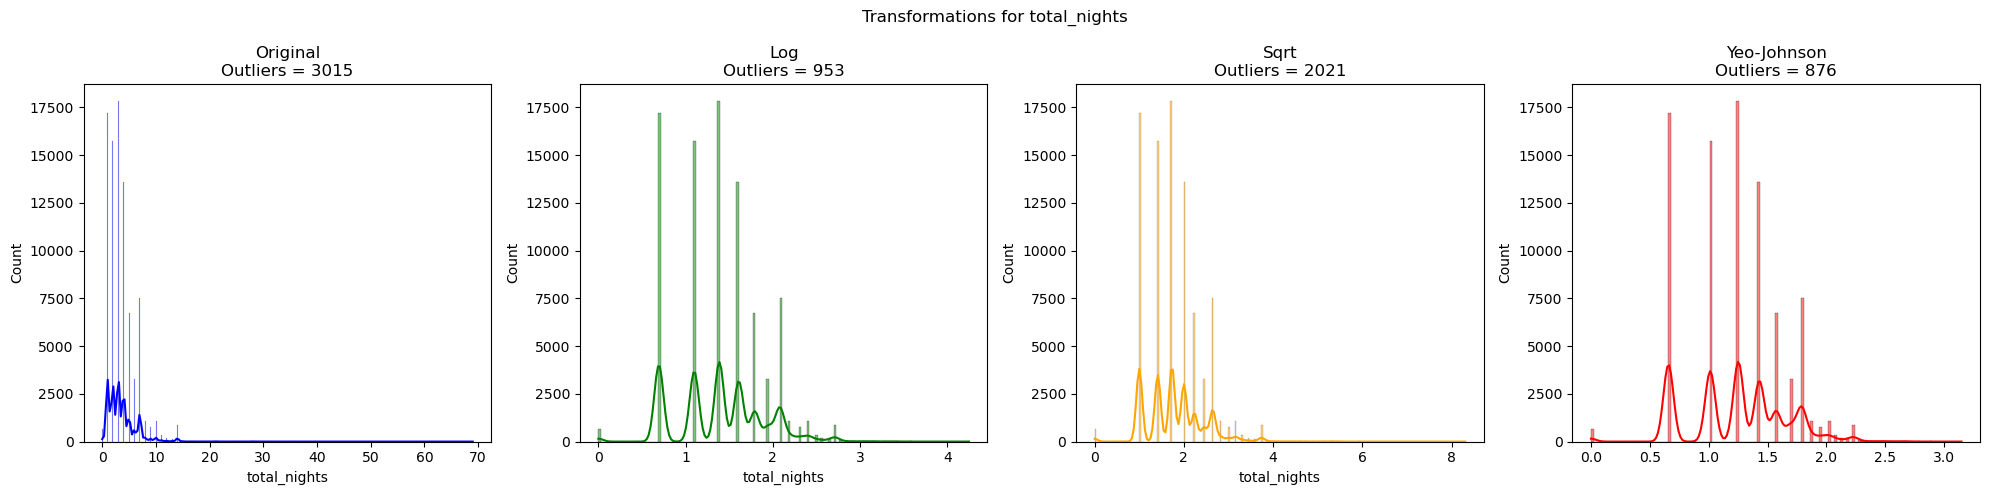

In [ ]:
cols = [
    'lead_time',
    'adr',
    'days_in_waiting_list',
    'total_nights'
]

for col in cols:
    plot_transformations(df, col)

### Outlier Handling Observation

We have visualized the distribution of numerical columns using boxplots, which reveal the presence of various outliers. In the data cleaning step, we specifically removed 'suspicious records' such as bookings with zero guests, zero nights, and negative ADR, as these are clearly invalid for a typical hotel booking cancellation model.

For other general outliers (e.g., very high `lead_time` or `adr`), we have chosen not to perform aggressive removal (e.g., using IQR methods for all columns) at this stage. The decision to keep these outliers is based on the understanding that they might represent legitimate, albeit extreme, booking behaviors (e.g., long-term bookings, very expensive stays). Removing them might lead to a loss of valuable information or make the model less generalizable to such real-world scenarios. Further outlier treatment can be explored as a modeling refinement if initial model performance indicates sensitivity to these extreme values.

In [ ]:
# Create total stay cost if it does not already exist
if "total_stay_cost" not in df.columns:
    df["total_stay_cost"] = df["adr"] * df["total_nights"]


# Skewness diagnostics for candidate continuous / continuous-like variables

skew_cols = [
    "lead_time",
    "adr",
    "days_in_waiting_list",
    "total_nights",
    "total_stay_cost"
]

skewness_df = (
    df[skew_cols]
    .skew()
    .sort_values(ascending=False)
    .to_frame("skewness")
)

skewness_df["highly_skewed"] = (
    skewness_df["skewness"].abs() > 1
)

display(skewness_df)

,skewness,highly_skewed
days_in_waiting_list,19.396419,True
adr,10.921447,True
total_nights,3.073162,True
total_stay_cost,2.708870,True
lead_time,1.431774,True


In [ ]:
# Candidate variables selected for the Log experiment
# All selected variables are non-negative after the cleaning step.

# Dynamically extract highly skewed columns for log transformation
log_cols = skewness_df[skewness_df["highly_skewed"]].index.tolist()

print("Log experiment columns:")
print(log_cols)

Log experiment columns:
['days_in_waiting_list', 'adr', 'total_nights', 'total_stay_cost', 'lead_time']


### 2.6 Remove Invalid Records

Only logically invalid records are removed:
- zero guests
- zero nights
- negative ADR

IQR outliers in legitimate booking/count variables are retained.

In [ ]:
# Remove logically invalid records only

df = df[df["total_guests"] > 0].copy()
df = df[df["total_nights"] > 0].copy()
df = df[df["adr"] >= 0].copy()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (86638, 34)


## 3. Feature Engineering

The following variables are created because they summarize information already present in the raw data in a more useful form:
- `total_guests`
- `total_nights`
- `total_stay_cost`
- `is_family`
- `is_weekend_stay`
- `arrival month number`
- `day of week`
- `season`


In [ ]:
df["total_stay_cost"] = df["adr"] * df["total_nights"]

df["is_family"] = (
    (df["children"] > 0) | (df["babies"] > 0)
).astype(int)

df["is_weekend_stay"] = (
    df["stays_in_weekend_nights"] > 0
).astype(int)

# Room change indicator: 1 if the assigned room differs from the reserved room
df["room_changed"] = (
    df["assigned_room_type"] != df["reserved_room_type"]
).astype(int)

# A real arrival date
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["arrival_date_month"] + "-" +
    df["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d"
)

df["arrival_month_num"] = df["arrival_date"].dt.month
df["arrival_day_of_week"] = df["arrival_date"].dt.dayofweek

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    return "Autumn"

df["season"] = df["arrival_month_num"].apply(get_season)

print(df[[
    "total_guests",
    "total_nights",
    "total_stay_cost",
    "is_family",
    "is_weekend_stay",
    "room_changed",
    "arrival_month_num",
    "arrival_day_of_week",
    "season"
]].head())

   total_guests  total_nights  total_stay_cost  is_family  is_weekend_stay  \
2           1.0             1             75.0          0                0   
3           1.0             1             75.0          0                0   
4           2.0             2            196.0          0                0   
6           2.0             2            214.0          0                0   
7           2.0             2            206.0          0                0   

   room_changed  arrival_month_num  arrival_day_of_week  season  
2             1                  7                    2  Summer  
3             0                  7                    2  Summer  
4             0                  7                    2  Summer  
6             0                  7                    2  Summer  
7             0                  7                    2  Summer  


## 4. Prevent Data Leakage

`reservation_status` and `reservation_status_date` describe the final outcome of the reservation. Using them to predict `is_canceled` would give the model information that would not be available at prediction time.

Therefore, both variables are removed.

The raw `arrival_date` is also removed later because its useful information has already been extracted into separate features.

In [ ]:
df = df.drop(columns=[
    "reservation_status",
    "reservation_status_date"
])

print("Leakage columns removed.")
print("Current shape:", df.shape)

Leakage columns removed.
Current shape: (86638, 39)


## 5. Target Distribution

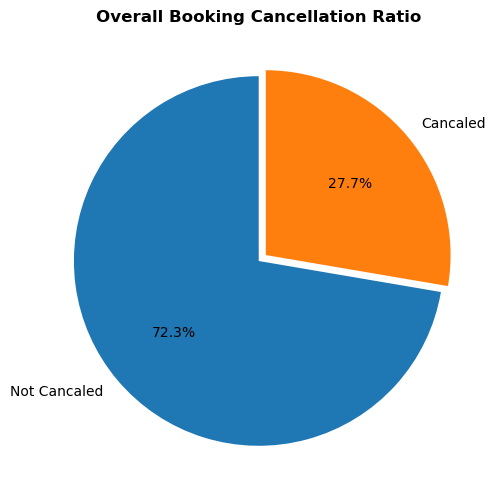

In [ ]:
plt.figure(figsize=(6, 6))

plt.pie(df["is_canceled"].value_counts(), labels = ["Not Cancaled", "Cancaled"], autopct='%1.1f%%', startangle=90, explode=(0, 0.05))
plt.title("Overall Booking Cancellation Ratio", fontweight='bold')
plt.show()

**Observation:** About 27.7% of the cleaned bookings are canceled, while about 72.3% are not canceled. This is a moderate class imbalance, so precision, recall, F1-score and ROC-AUC should be considered during model evaluation.

## 6. Cancellation Rate by Hotel

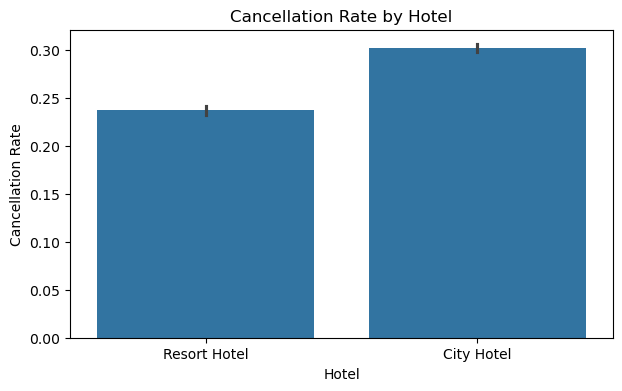

In [ ]:
hotel_cancel = (
    df.groupby("hotel")["is_canceled"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
sns.barplot(data=df, x="hotel", y="is_canceled")
plt.title("Cancellation Rate by Hotel")
plt.xlabel("Hotel")
plt.ylabel("Cancellation Rate")
plt.show()


**Observation:** City Hotel bookings have a higher cancellation rate than Resort Hotel bookings, indicating that hotel type is potentially useful for prediction.

## 7. Lead Time vs Cancellation

Lead time is the number of days between booking and arrival. We examine both its distribution and cancellation rate by groups.

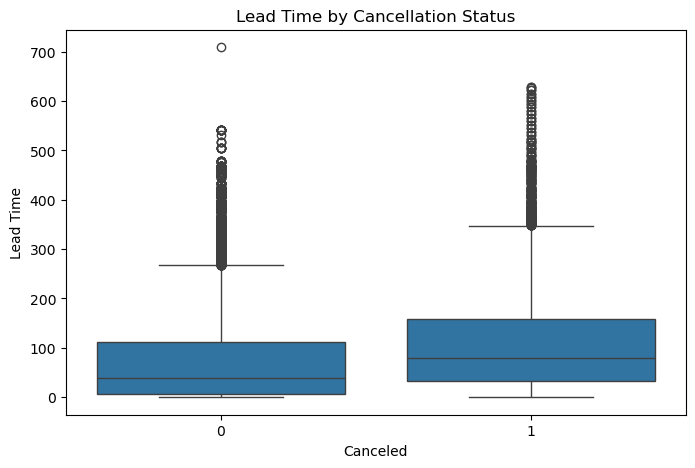

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_canceled", y="lead_time")
plt.title("Lead Time by Cancellation Status")
plt.xlabel("Canceled")
plt.ylabel("Lead Time")
plt.show()

In [ ]:
df["lead_time_group"] = pd.cut(
    df["lead_time"],
    bins=[-1, 6, 29, 89, 179, 364, np.inf],
    labels=["0-6", "7-29", "30-89", "90-179", "180-364", "365+"]
)

lead_cancel = df.groupby(
    "lead_time_group", observed=False
)["is_canceled"].mean()

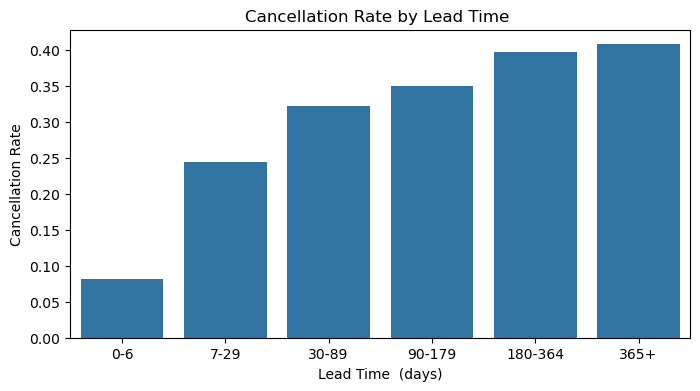

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(x=lead_cancel.index.astype(str), y=lead_cancel.values)
plt.title("Cancellation Rate by Lead Time ")
plt.xlabel("Lead Time  (days)")
plt.ylabel("Cancellation Rate")
plt.show()

**Observation:** Cancellation rate generally increases as lead time becomes longer. Bookings made far in advance are more likely to be canceled than bookings made shortly before arrival.

## 8. Deposit Type

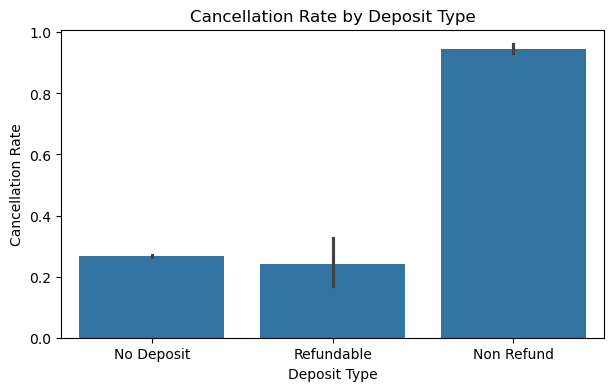

In [ ]:
deposit_cancel = (
    df.groupby("deposit_type")["is_canceled"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
sns.barplot(data=df, x="deposit_type", y="is_canceled")
plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate")
plt.show()

**Observation:** Deposit type has one of the strongest relationships with cancellation. Non-refundable bookings show a much higher observed cancellation rate than the other deposit categories. This is an association, not proof that deposit type itself causes cancellation.

## 9. Market Segment

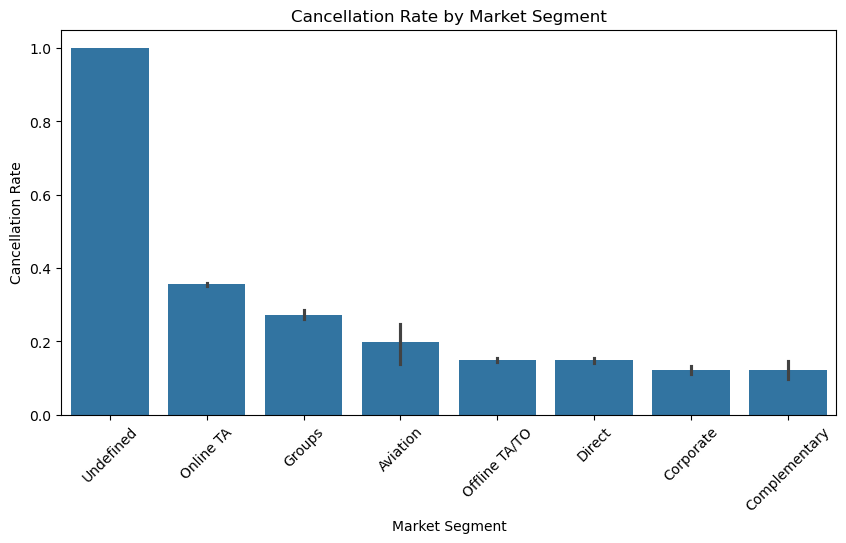

In [ ]:
segment_cancel = (
    df.groupby("market_segment")["is_canceled"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x="market_segment",
    y="is_canceled",
    order=segment_cancel.index
)
plt.xticks(rotation=45)
plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate")
plt.show()

**Observation:** Online travel agency bookings have a relatively high cancellation rate, while direct and corporate bookings have lower cancellation rates.


## 10. Customer Type

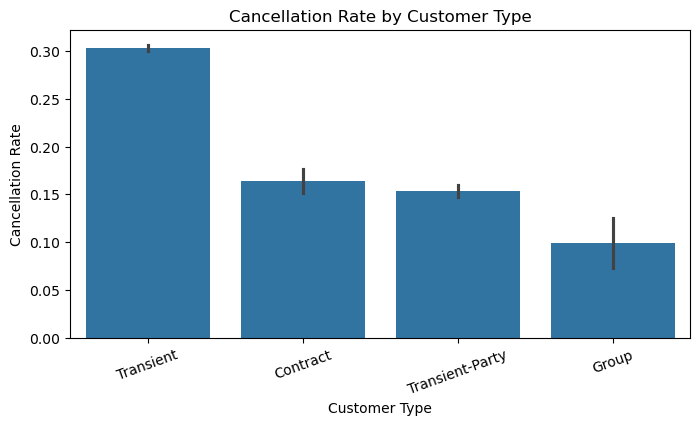

In [ ]:
customer_cancel = (
    df.groupby("customer_type")["is_canceled"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
sns.barplot(data=df, x="customer_type", y="is_canceled")
plt.xticks(rotation=20)
plt.title("Cancellation Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Cancellation Rate")
plt.show()

**Observation:** Transient customers have a higher cancellation rate than group and contract customers.

## 11. Repeated Guests

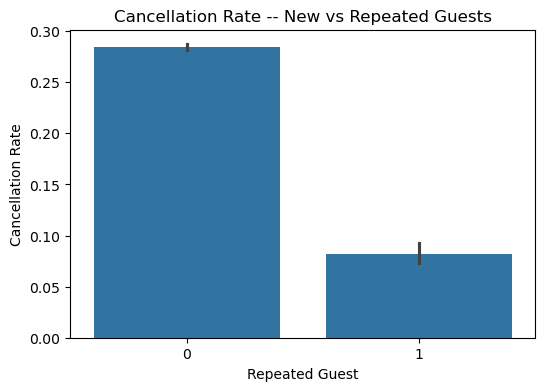

In [ ]:
repeat_cancel = df.groupby("is_repeated_guest")["is_canceled"].mean()

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="is_repeated_guest", y="is_canceled")
plt.title("Cancellation Rate -- New vs Repeated Guests")
plt.xlabel("Repeated Guest")
plt.ylabel("Cancellation Rate")
plt.show()

**Observation:** Repeated guests have lower cancellation rate than first-time guests, suggesting that customer history is useful for predicting cancellations.

## 12. Special Requests

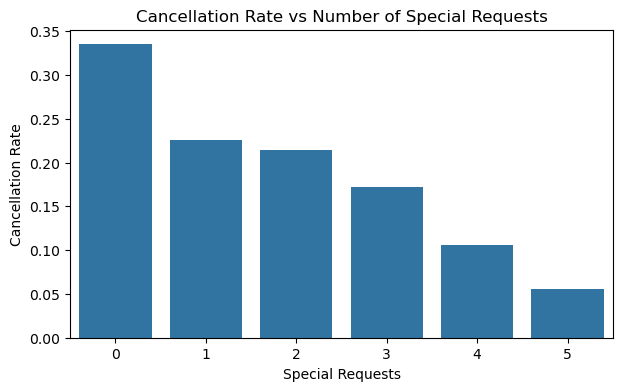

In [ ]:
request_cancel = (
    df.groupby("total_of_special_requests")["is_canceled"]
      .mean()
)

plt.figure(figsize=(7, 4))
sns.barplot(
    x=request_cancel.index,
    y=request_cancel.values
)
plt.title("Cancellation Rate vs Number of Special Requests")
plt.xlabel("Special Requests")
plt.ylabel("Cancellation Rate")
plt.show()

**Observation:** Cancellation generally decreases as the number of special requests increases. This may indicate stronger engagement with the booking.

## 13. ADR (Average Daily Rate)

In [ ]:
df.groupby("is_canceled")["adr"].agg(["mean", "median", "std"])

,mean,median,std
is_canceled,,,
0,103.142605,95.0,50.535300
1,117.963968,109.8,62.017836


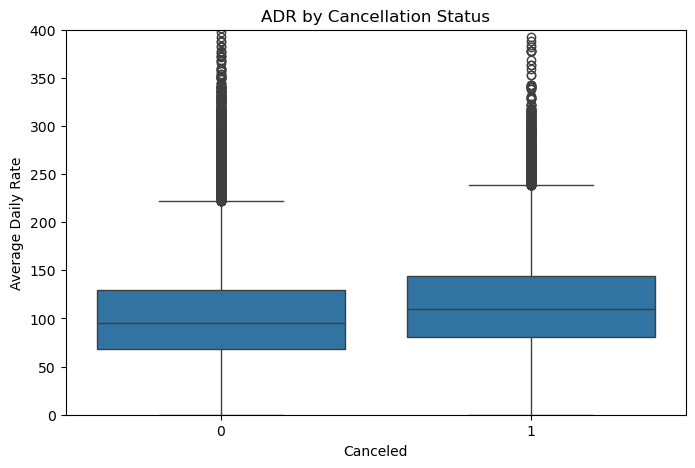

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_canceled", y="adr")
plt.ylim(0, 400)
plt.title("ADR by Cancellation Status")
plt.xlabel("Canceled")
plt.ylabel("Average Daily Rate")
plt.show()

**Observation:** Canceled bookings have a higher average ADR than non-canceled bookings. The relationship should be investigated together with other variables because ADR may interact with hotel type, season and market segment.

## 14. Seasonal / Monthly Pattern

In [ ]:
month_cancel = (
    df.groupby(["arrival_month_num", "arrival_date_month"])["is_canceled"]
      .mean()
      .reset_index()
      .sort_values("arrival_month_num")
)

display(month_cancel)

,arrival_month_num,arrival_date_month,is_canceled
0,1,January,0.222941
1,2,February,0.233002
2,3,March,0.245598
3,4,April,0.305337
4,5,May,0.294118
5,6,June,0.304494
6,7,July,0.319884
7,8,August,0.323566
8,9,September,0.246283
9,10,October,0.239842


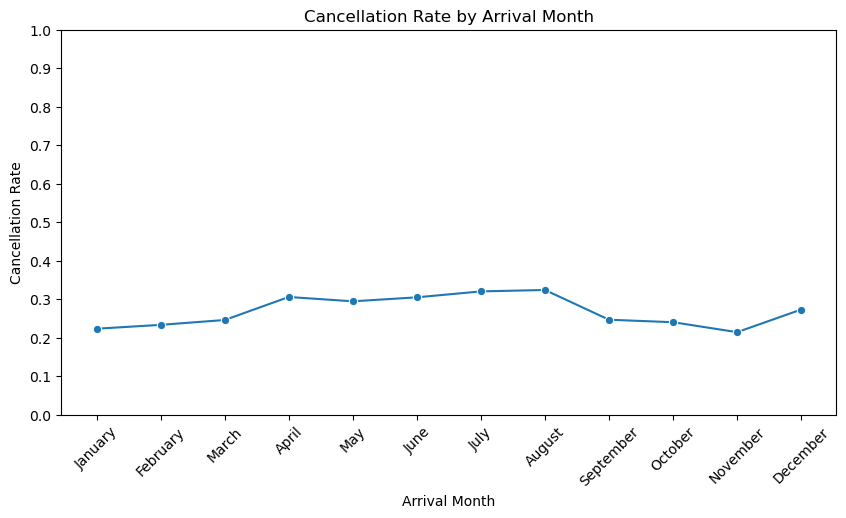

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=month_cancel,
    x="arrival_date_month",
    y="is_canceled",
    marker="o"
)

plt.xticks(rotation=45)

plt.ylim(0, 1)
plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

plt.title("Cancellation Rate by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Cancellation Rate")

plt.show()

**Observation:** Cancellation rates vary across arrival months, indicating that seasonality may contribute to cancellation behavior.

## 15. Exploring Engineered Features

#### Family Bookings

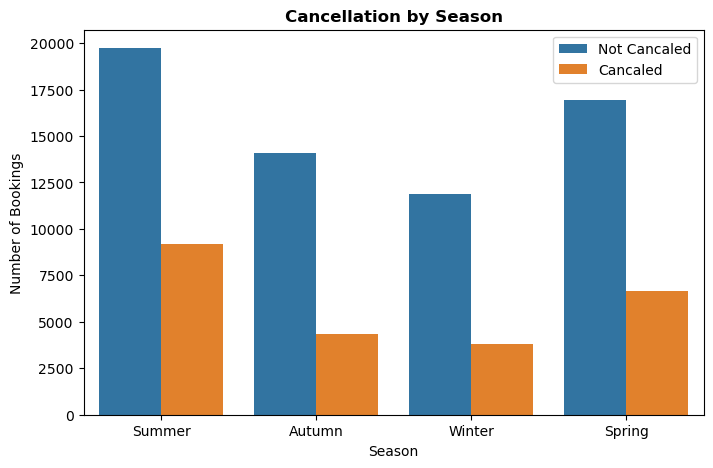

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data = df, x = "season", hue = "is_canceled", )
plt.title("Cancellation by Season", fontweight='bold')
plt.xlabel("Season")
plt.ylabel("Number of Bookings")
plt.legend(labels = ["Not Cancaled", "Cancaled"])
plt.show()

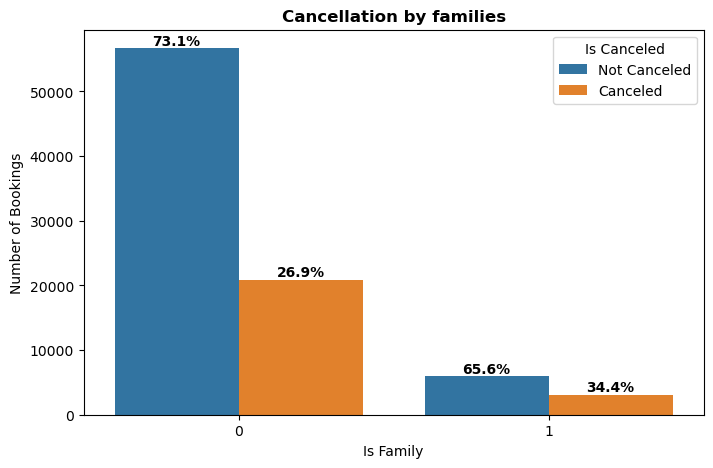

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="is_family",
    hue="is_canceled"
)

plt.title("Cancellation by families", fontweight="bold")
plt.xlabel("Is Family")
plt.ylabel("Number of Bookings")

# Add percentages
for family in sorted(df["is_family"].unique()):

    family_data = df[df["is_family"] == family]
    total = len(family_data)

    for canceled in [0, 1]:

        count = len(
            family_data[
                family_data["is_canceled"] == canceled
            ]
        )

        percentage = (count / total) * 100

        # Position of the bar
        x_position = family + (-0.2 if canceled == 0 else 0.2)

        if count > 0:
            ax.text(
                x_position,
                count,
                f"{percentage:.1f}%",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold"
            )

plt.legend(
    labels=["Not Canceled", "Canceled"],
    title="Is Canceled"
)

plt.show()

**Observation:** Family bookings show a slightly higher cancellation rate than non-family bookings, though families make up a small share of total bookings.

#### Number of Guests

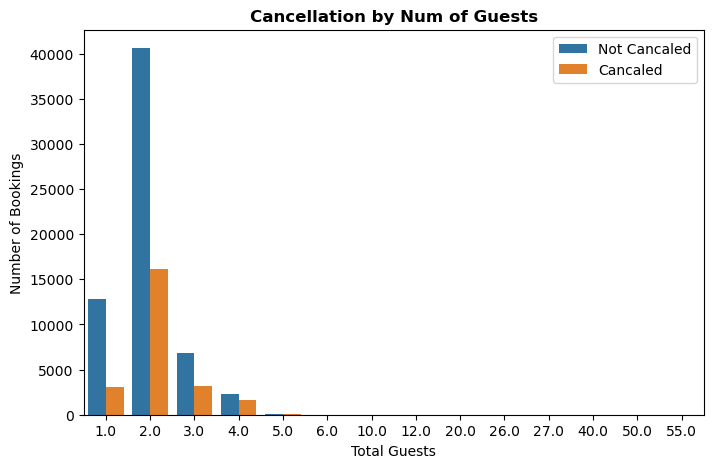

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data = df, x = "total_guests", hue = "is_canceled")
plt.title("Cancellation by Num of Guests", fontweight='bold')
plt.xlabel("Total Guests")
plt.ylabel("Number of Bookings")
plt.legend(labels = ["Not Cancaled", "Cancaled"])
plt.show()

**Observation:** Cancellation rate tends to increase with the number of guests, single-guest bookings cancel least often, while bookings with more than 3 guests show a higher cancellation share.

###Season

**Observation:** Summer has both the highest number of bookings and the highest
cancellation count, while Winter has the fewest bookings and cancellations overall.

#### Total Nights

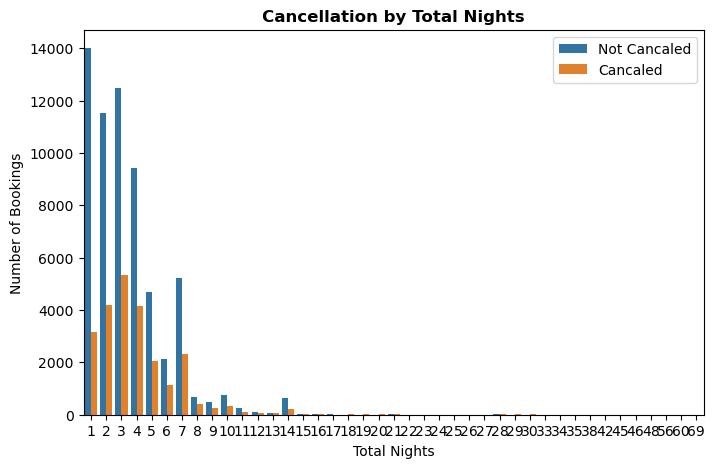

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data = df, x = "total_nights", hue = "is_canceled")
plt.title("Cancellation by Total Nights", fontweight='bold')
plt.xlabel("Total Nights")
plt.ylabel("Number of Bookings")
plt.legend(labels = ["Not Cancaled", "Cancaled"])
plt.show()

**Observation:** Most stays are short (1-4 nights). Cancellation share appears to increase somewhat for longer stays, such as around the 7-night mark

## 16. Cancellation Rate by Guest Country

We restrict this view to countries with at least 100 bookings to avoid noisy rates from very small samples.

In [ ]:
country_stats = df.groupby('country').agg(
    bookings=('is_canceled', 'size'),
    cancel_rate=('is_canceled', 'mean')
).reset_index()

country_stats = country_stats[country_stats['bookings'] >= 100]

fig = px.choropleth(
    country_stats,
    locations='country',
    color='cancel_rate',
    hover_name='country',
    hover_data=['bookings'],
    color_continuous_scale='Reds',
    labels={'cancel_rate': 'Cancellation Rate'},
    title='Cancellation Rate by Guest Country (min. 100 bookings)'
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.show()

**Observation:** Cancellation rates vary notably by guest country. China, for example, shows a 48.1% cancellation rate (815 bookings), well above the 27.7% baseline, suggesting `country` is a potentially useful predictor.

## 17. Numerical Correlations with Cancellation

In [ ]:
numeric_cols = [
    "is_canceled",
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

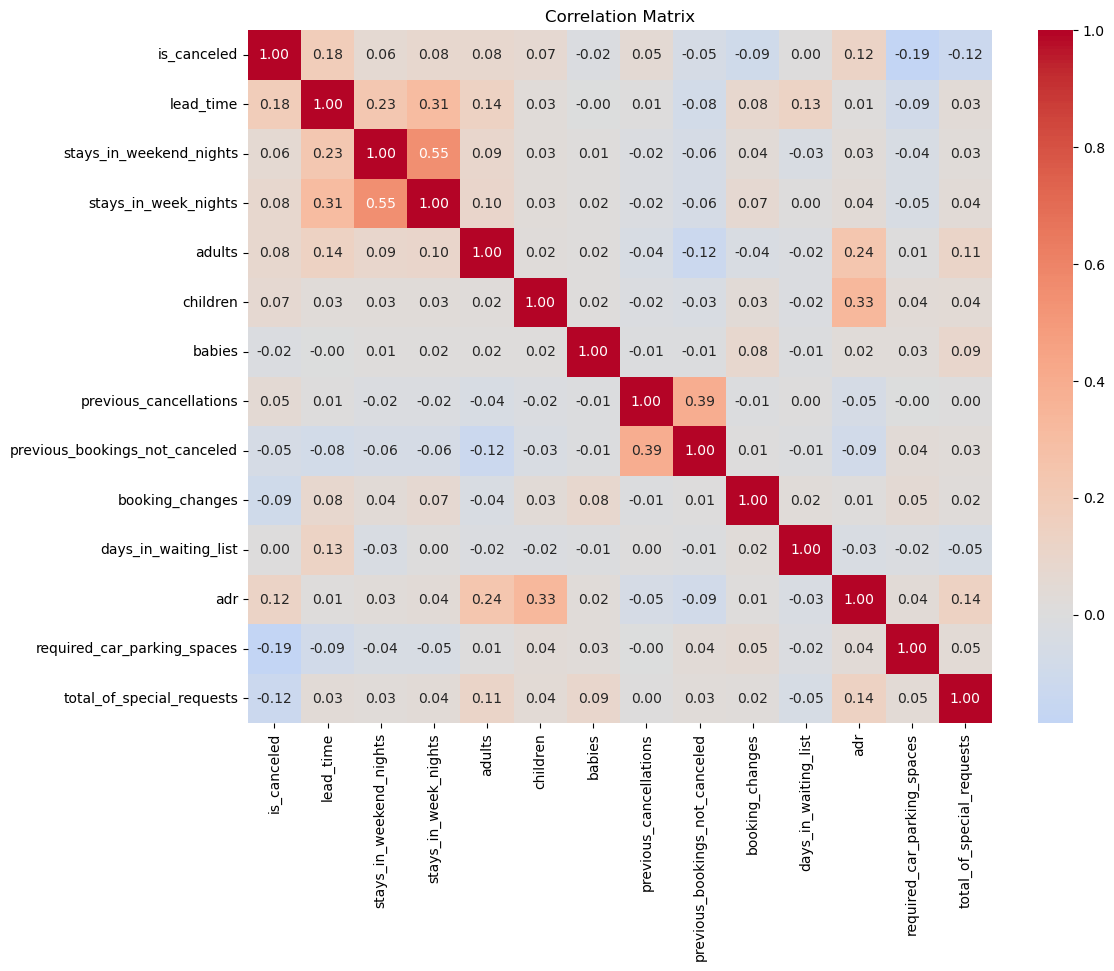

In [ ]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# too many variables, we can view it by sorting the values in a single column Dataframe.
print("Correlations with is_canceled:")
display(
    corr["is_canceled"]
    .sort_values(ascending=False)
    .to_frame("correlation")
)

Correlations with is_canceled:


,correlation
is_canceled,1.000000
lead_time,0.183507
adr,0.121986
stays_in_week_nights,0.080109
adults,0.079811
children,0.067055
stays_in_weekend_nights,0.057767
previous_cancellations,0.051371
days_in_waiting_list,0.004520
babies,-0.020738


#### Engineered Feature Correlations

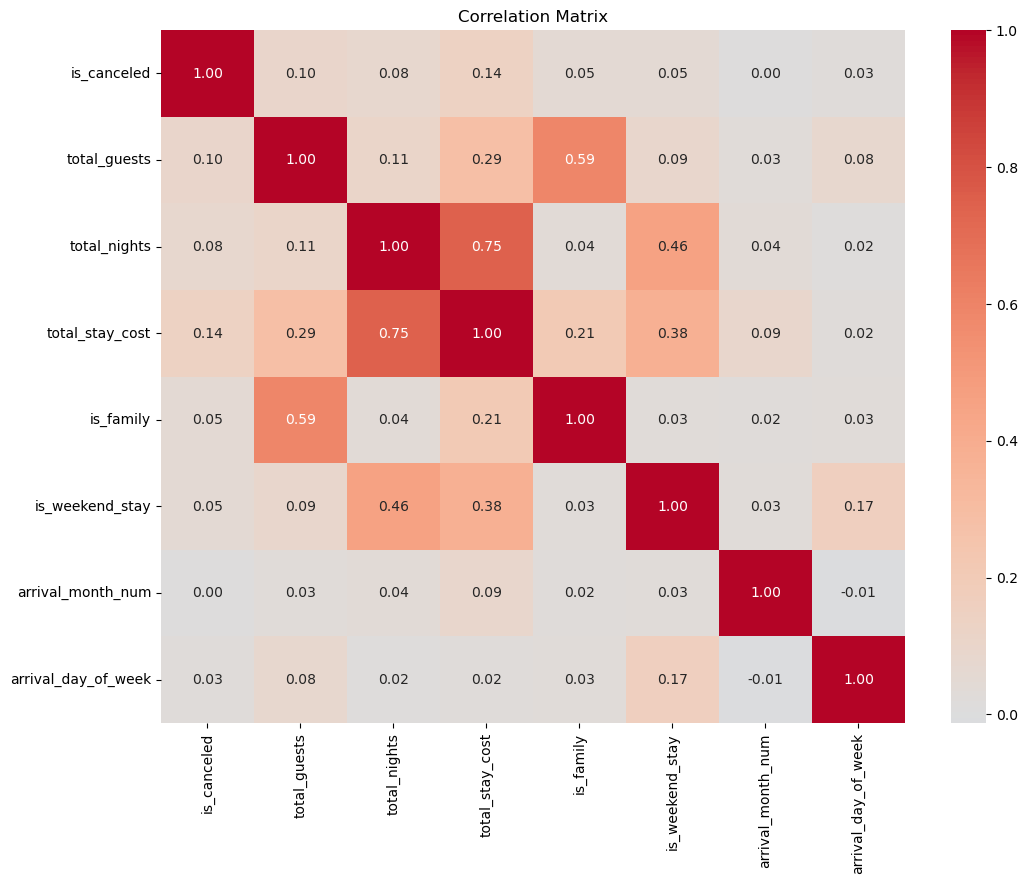

In [ ]:
corr = df[['is_canceled','total_guests', 'total_nights', 'total_stay_cost', 'is_family','is_weekend_stay','arrival_month_num','arrival_day_of_week']].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.show()

###Pairwise Relationships

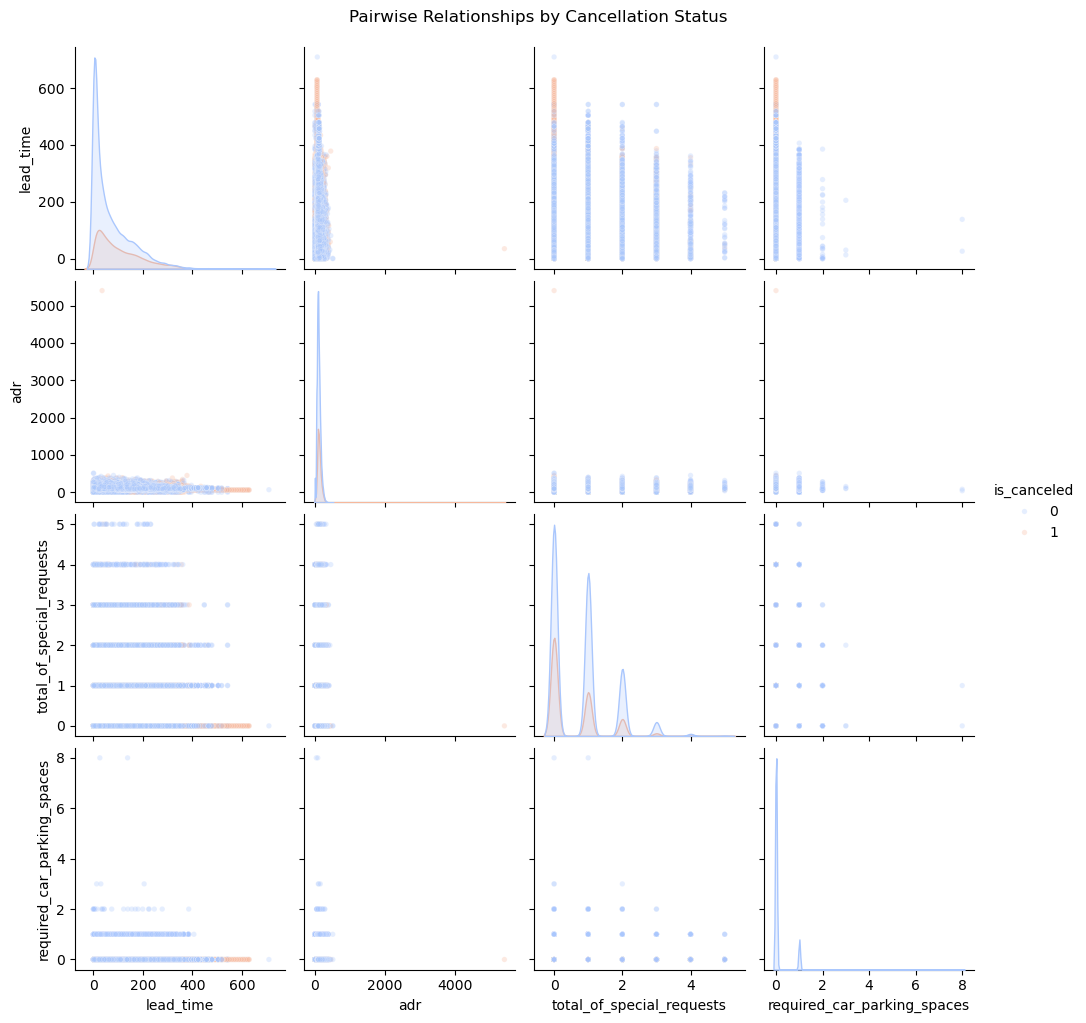

In [ ]:
cols = ['lead_time', 'adr', 'total_of_special_requests',
        'required_car_parking_spaces', 'is_canceled']

sns.pairplot(df[cols], hue='is_canceled',
             plot_kws={'alpha': 0.3, 's': 15},
             diag_kind='kde', palette='coolwarm')
plt.suptitle('Pairwise Relationships by Cancellation Status', y=1.02)
plt.show()

## 18. Final Preprocessing and Log Experiment Setup

We build two versions of the same cleaned dataset:
- **Experiment A — Without Log:** original feature distributions.
- **Experiment B — With Log:** `log1p` applied only to the selected skewed continuous/continuous-like features.

The same train/test indices, models, cross-validation strategy, and evaluation metrics are used for both experiments.

In [ ]:
# Drop columns after the information we need has already been extracted
# - agent: excluded from the final feature set
# - arrival_date_year: used to create arrival_date, then removed
# - arrival_date_week_number: redundant after arrival date features are created
# - original room columns: replaced by room_changed
# - arrival_date: extracted into month/day-of-week/season, so it is removed before ML

drop_cols = [
    "agent",
    "arrival_date_year",
    "arrival_date_week_number",
    "assigned_room_type",
    "reserved_room_type",
    "arrival_date"
]

df_model = df.drop(columns=drop_cols, errors="ignore").copy()

# Two identical copies before transformation
df_no_log = df_model.copy()
df_log = df_model.copy()

# Apply log1p safely to the selected non-negative continuous/continuous-like variables
log_cols = [
    "lead_time",
    "adr",
    "days_in_waiting_list",
    "total_nights",
    "total_stay_cost"
]

for col in log_cols:
    df_log[col] = np.log1p(df_log[col])

print("Final no-log shape:", df_no_log.shape)
print("Final log shape:", df_log.shape)

Final no-log shape: (86638, 34)
Final log shape: (86638, 34)


## 19. Encoding and Identical Train/Test Split

Categorical variables are one-hot encoded. `country` is frequency encoded because it is high-cardinality. The same random train/test split is reused for both experiments so the comparison isolates the effect of the Log Transformation.

In [ ]:
def prepare_encoded_data(data):
    data = data.copy()

    # Frequency encoding for high-cardinality country
    country_freq = data["country"].value_counts(normalize=True)
    data["country_freq"] = data["country"].map(country_freq)
    data = data.drop(columns=["country"], errors="ignore")

    categorical_cols = [
        "hotel",
        "arrival_date_month",
        "meal",
        "market_segment",
        "distribution_channel",
        "deposit_type",
        "customer_type",
        "season",
        "lead_time_group"
    ]

    categorical_cols = [c for c in categorical_cols if c in data.columns]
    encoded = pd.get_dummies(
        data,
        columns=categorical_cols,
        drop_first=True,
        dtype=int
    )

    return encoded


df_no_log_encoded = prepare_encoded_data(df_no_log)
df_log_encoded = prepare_encoded_data(df_log)

# Align columns so both experiments use exactly the same feature space
X_no_log = df_no_log_encoded.drop(columns=["is_canceled"])
y = df_no_log_encoded["is_canceled"].astype(int)

X_log = df_log_encoded.drop(columns=["is_canceled"])
y_log = df_log_encoded["is_canceled"].astype(int)

X_log = X_log.reindex(columns=X_no_log.columns, fill_value=0)

# Create ONE split and reuse the exact indices for both experiments
train_idx, test_idx = train_test_split(
    np.arange(len(y)),
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_train_no_log = X_no_log.iloc[train_idx].copy()
X_test_no_log = X_no_log.iloc[test_idx].copy()
X_train_log = X_log.iloc[train_idx].copy()
X_test_log = X_log.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

y_train_log = y_log.iloc[train_idx].copy()
y_test_log = y_log.iloc[test_idx].copy()

print("Train shape:", X_train_no_log.shape)
print("Test shape:", X_test_no_log.shape)
print("Same target split:", y_train.equals(y_train_log) and y_test.equals(y_test_log))

Train shape: (60646, 64)
Test shape: (25992, 64)
Same target split: True


## 20. Modeling Function

The same three classifiers are evaluated in both experiments:
- Random Forest
- Logistic Regression
- XGBoost

Logistic Regression uses a `Pipeline` so `StandardScaler` is fitted inside each cross-validation fold, avoiding preprocessing leakage.

In [ ]:
def evaluate_experiment(X_train, X_test, y_train, y_test, X_all, y_all, experiment_name):
    models = {
        "Random Forest": RandomForestClassifier(
            n_estimators=100, random_state=42, class_weight="balanced", n_jobs=-1
        ),
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                random_state=42, class_weight="balanced",
                solver="liblinear", max_iter=1000
            ))
        ]),
        "XGBoost": XGBClassifier(
            n_estimators=100, random_state=42,
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            eval_metric="logloss", n_jobs=-1
        )
    }

    rows, cv_rows, predictions, importances = [], [], {}, {}
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        rows.append({
            "Experiment": experiment_name, "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_prob)
        })

        cv_scores = cross_val_score(model, X_all, y_all, cv=skf, scoring="roc_auc", n_jobs=-1)
        cv_rows.append({
            "Experiment": experiment_name, "Model": model_name,
            "CV ROC-AUC Mean": cv_scores.mean(), "CV ROC-AUC Std": cv_scores.std()
        })

        predictions[model_name] = {"model": model, "y_pred": y_pred, "y_prob": y_prob}

        # --- Feature importance / coefficients ---
        if model_name == "Logistic Regression":
            # coefficients come from the fitted 'model' step inside the pipeline
            coefs = model.named_steps["model"].coef_[0]
            imp_df = pd.DataFrame({
                "Feature": X_train.columns,
                "Importance": coefs
            }).assign(AbsImportance=lambda d: d["Importance"].abs()) \
              .sort_values("AbsImportance", ascending=False) \
              .drop(columns="AbsImportance")
        else:
            # Random Forest and XGBoost both expose feature_importances_
            imp_df = pd.DataFrame({
                "Feature": X_train.columns,
                "Importance": model.feature_importances_
            }).sort_values("Importance", ascending=False)

        importances[model_name] = imp_df

    return pd.DataFrame(rows), pd.DataFrame(cv_rows), predictions, importances

In [ ]:
def plot_feature_importance(imp_dict, experiment_name, top_n=15):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, (model_name, imp_df) in zip(axes, imp_dict.items()):
        top = imp_df.head(top_n)
        sns.barplot(data=top, x="Importance", y="Feature", ax=ax)
        ax.set_title(f"{model_name} — {experiment_name}")
    plt.tight_layout()
    plt.show()

### Experiment A — Without Log

In [ ]:
results_no_log, cv_no_log, pred_no_log, imp_no_log = evaluate_experiment(
    X_train_no_log,
    X_test_no_log,
    y_train,
    y_test,
    X_no_log,
    y,
    "Without Log"
)

display(results_no_log.round(4))
display(cv_no_log.round(4))

,Experiment,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Without Log,Random Forest,0.8340,0.7516,0.5982,0.6662,0.8927
1,Without Log,Logistic Regression,0.7453,0.5261,0.8056,0.6365,0.8472
2,Without Log,XGBoost,0.8090,0.6160,0.8234,0.7048,0.8994


,Experiment,Model,CV ROC-AUC Mean,CV ROC-AUC Std
0,Without Log,Random Forest,0.8950,0.0014
1,Without Log,Logistic Regression,0.8460,0.0017
2,Without Log,XGBoost,0.9002,0.0016


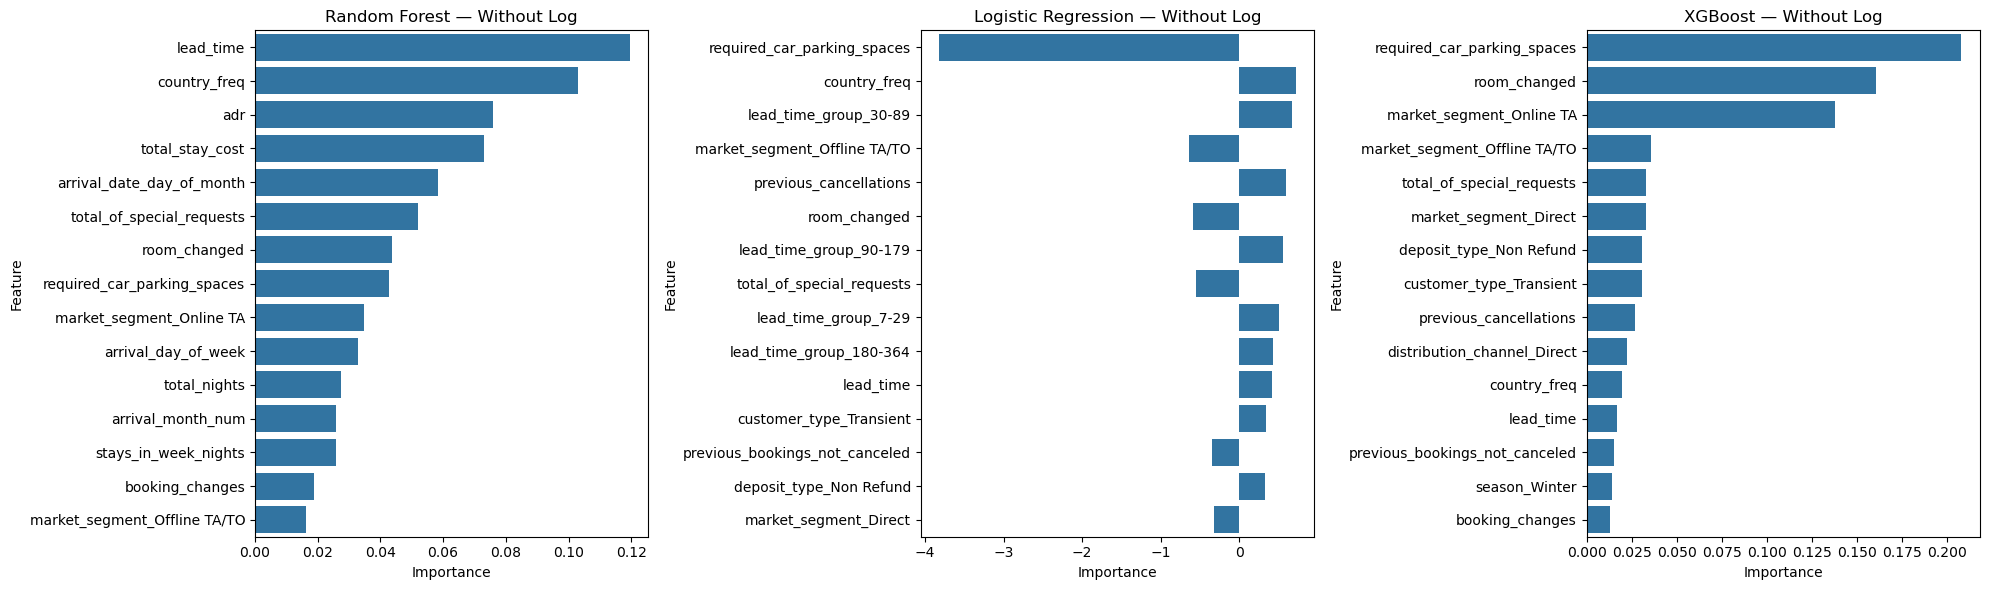

In [ ]:
plot_feature_importance(imp_no_log, "Without Log")

### Experiment B — With Log

In [ ]:
results_log, cv_log, pred_log, imp_log = evaluate_experiment(
    X_train_log,
    X_test_log,
    y_train_log,
    y_test_log,
    X_log,
    y_log,
    "With Log"
)

display(results_log.round(4))
display(cv_log.round(4))

,Experiment,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,With Log,Random Forest,0.834,0.7512,0.5987,0.6663,0.8927
1,With Log,Logistic Regression,0.744,0.5244,0.8067,0.6356,0.8466
2,With Log,XGBoost,0.809,0.6160,0.8234,0.7048,0.8994


,Experiment,Model,CV ROC-AUC Mean,CV ROC-AUC Std
0,With Log,Random Forest,0.8951,0.0014
1,With Log,Logistic Regression,0.8457,0.0020
2,With Log,XGBoost,0.9002,0.0016


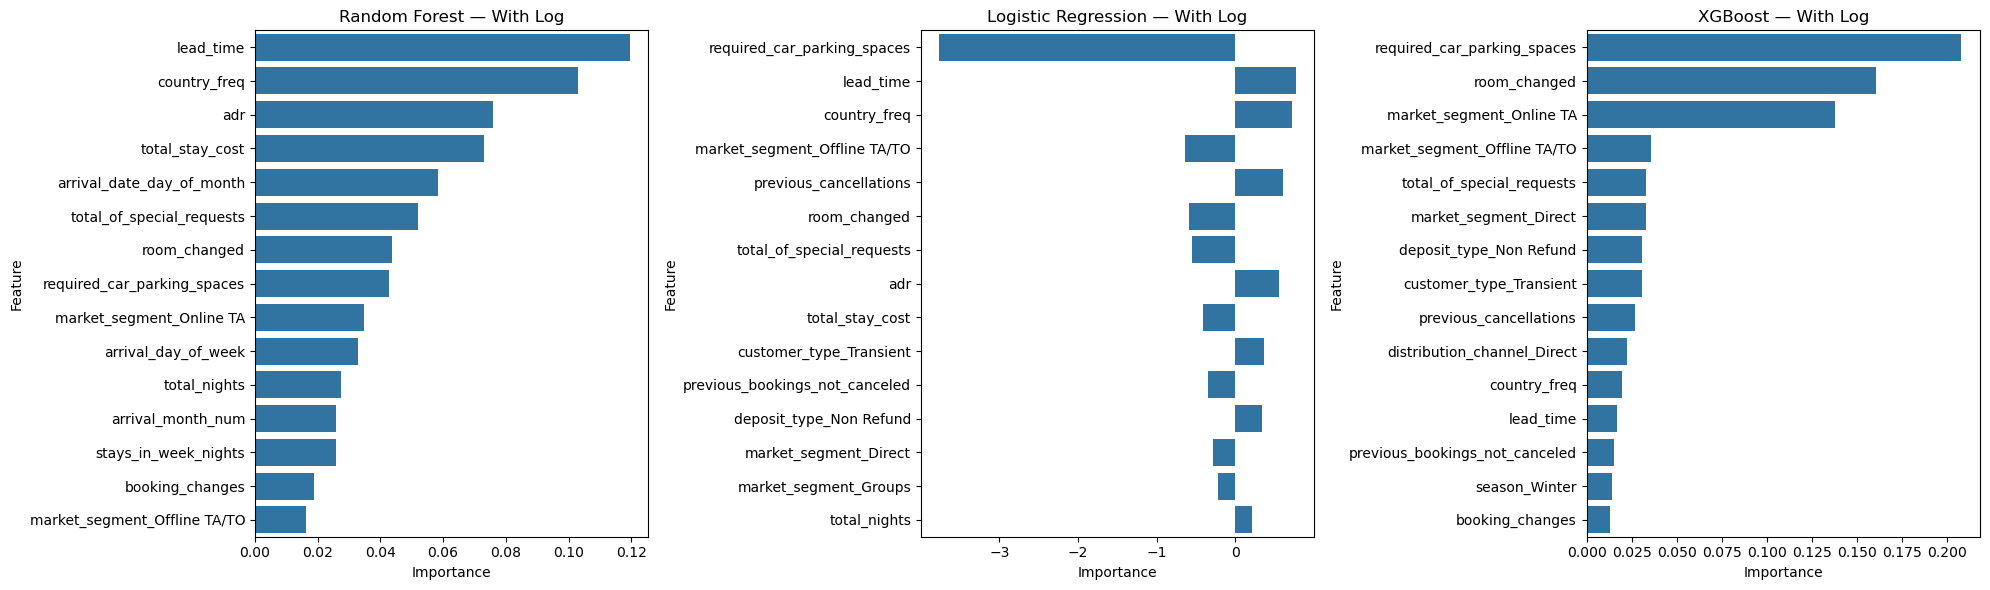

In [ ]:
plot_feature_importance(imp_log, "With Log")

## 21. Without Log vs With Log Comparison

In [ ]:
# Combine test-set metrics
comparison_metrics = pd.concat(
    [results_no_log, results_log],
    ignore_index=True
).sort_values(["Model", "Experiment"])

print("Test-set comparison:")
display(comparison_metrics.round(4))

# Direct Log improvement table
pivot_f1 = comparison_metrics.pivot(
    index="Model", columns="Experiment", values="F1-Score"
)
pivot_auc = comparison_metrics.pivot(
    index="Model", columns="Experiment", values="ROC-AUC"
)

improvement = pd.DataFrame({
    "F1 Change (With - Without)": pivot_f1["With Log"] - pivot_f1["Without Log"],
    "ROC-AUC Change (With - Without)": pivot_auc["With Log"] - pivot_auc["Without Log"]
})

print("Effect of Log Transformation:")
display(improvement.round(4))

Test-set comparison:


,Experiment,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,With Log,Logistic Regression,0.7440,0.5244,0.8067,0.6356,0.8466
1,Without Log,Logistic Regression,0.7453,0.5261,0.8056,0.6365,0.8472
3,With Log,Random Forest,0.8340,0.7512,0.5987,0.6663,0.8927
0,Without Log,Random Forest,0.8340,0.7516,0.5982,0.6662,0.8927
5,With Log,XGBoost,0.8090,0.6160,0.8234,0.7048,0.8994
2,Without Log,XGBoost,0.8090,0.6160,0.8234,0.7048,0.8994


Effect of Log Transformation:


,F1 Change (With - Without),ROC-AUC Change (With - Without)
Model,,
Logistic Regression,-0.0009,-0.0006
Random Forest,0.0001,0.0000
XGBoost,0.0000,0.0000


In [ ]:
# Cross-validation comparison
cv_comparison = pd.concat(
    [cv_no_log, cv_log],
    ignore_index=True
).sort_values(["Model", "Experiment"])

print("5-Fold Cross-Validation ROC-AUC:")
display(cv_comparison.round(4))

5-Fold Cross-Validation ROC-AUC:


,Experiment,Model,CV ROC-AUC Mean,CV ROC-AUC Std
4,With Log,Logistic Regression,0.8457,0.0020
1,Without Log,Logistic Regression,0.8460,0.0017
3,With Log,Random Forest,0.8951,0.0014
0,Without Log,Random Forest,0.8950,0.0014
5,With Log,XGBoost,0.9002,0.0016
2,Without Log,XGBoost,0.9002,0.0016


## 22. ROC Curve Comparison

ROC curves are plotted on the same test set for each model, comparing the two preprocessing experiments.

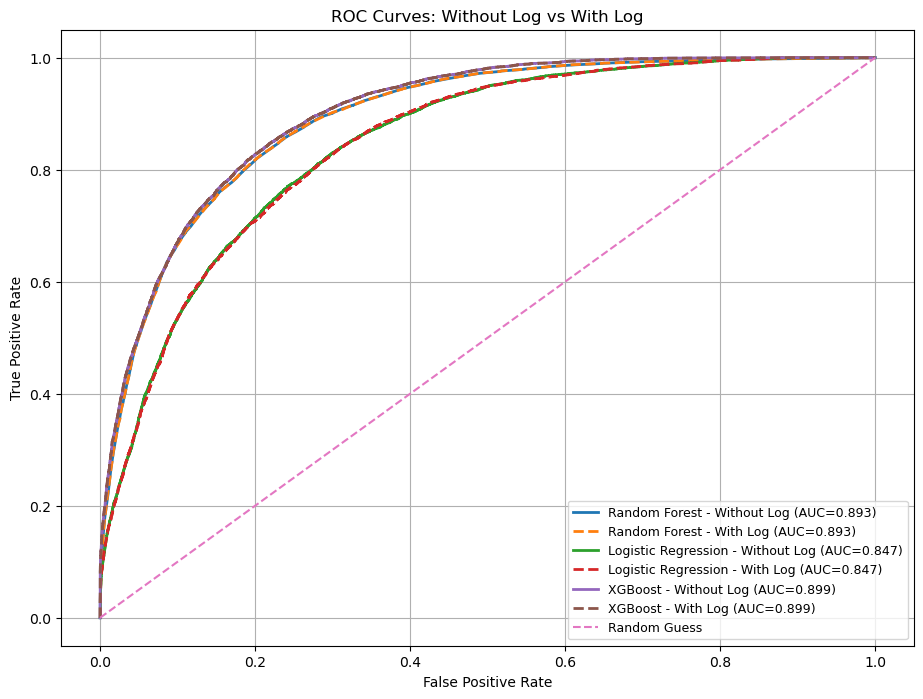

In [ ]:
plt.figure(figsize=(11, 8))

for model_name in ["Random Forest", "Logistic Regression", "XGBoost"]:
    fpr_no, tpr_no, _ = roc_curve(
        y_test,
        pred_no_log[model_name]["y_prob"]
    )
    auc_no = auc(fpr_no, tpr_no)
    plt.plot(fpr_no, tpr_no, lw=2,
             label=f"{model_name} - Without Log (AUC={auc_no:.3f})")

    fpr_log, tpr_log, _ = roc_curve(
        y_test_log,
        pred_log[model_name]["y_prob"]
    )
    auc_log = auc(fpr_log, tpr_log)
    plt.plot(fpr_log, tpr_log, lw=2, linestyle="--",
             label=f"{model_name} - With Log (AUC={auc_log:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Without Log vs With Log")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)
plt.show()

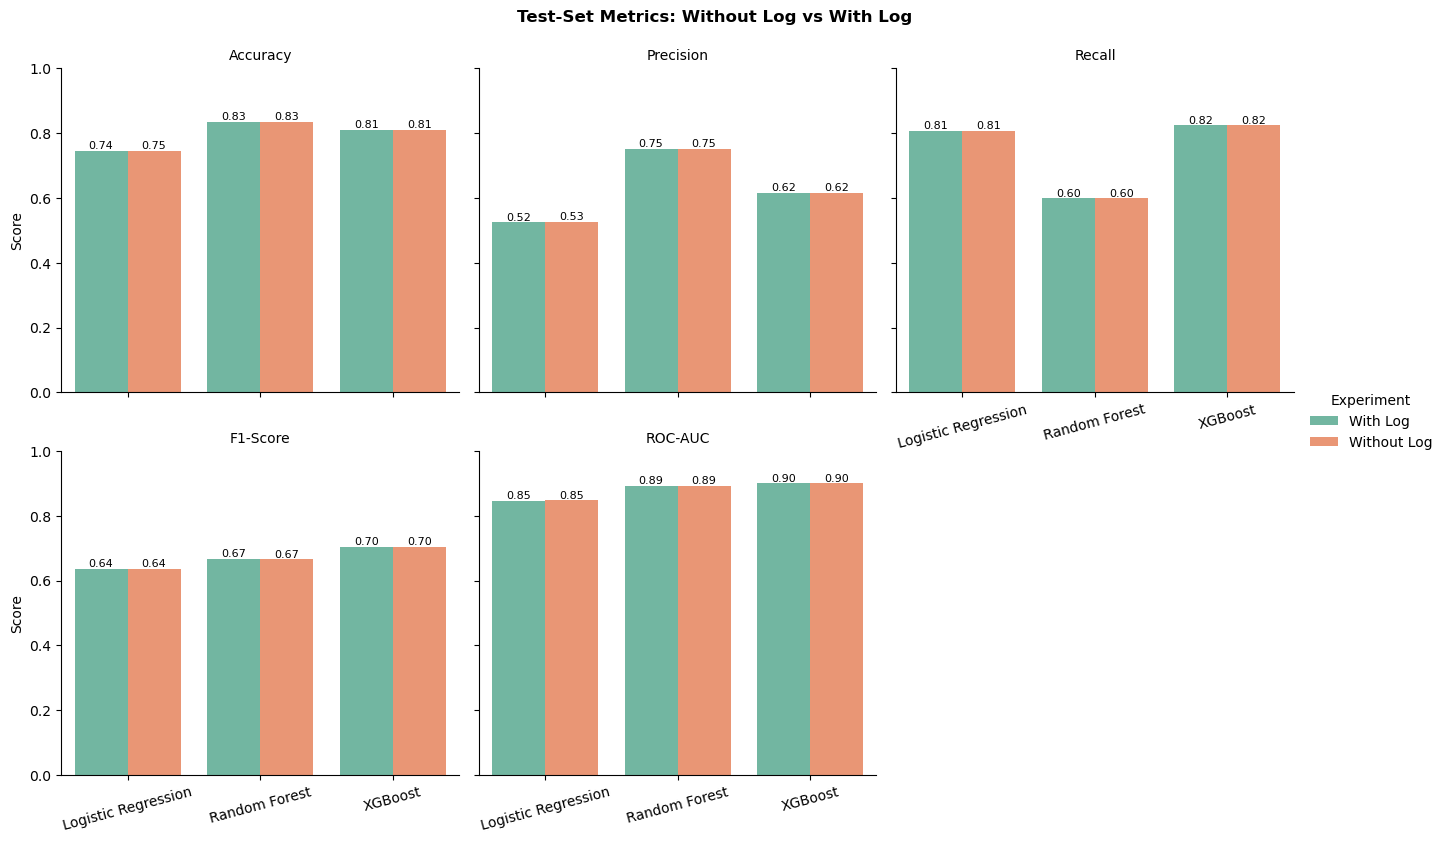

In [ ]:
# Reshape metrics into long format for grouped bar plots
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

melted_metrics = comparison_metrics.melt(
    id_vars=["Model", "Experiment"],
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

g = sns.catplot(
    data=melted_metrics,
    x="Model", y="Score", hue="Experiment",
    col="Metric", col_wrap=3,
    kind="bar", height=4, aspect=1.1,
    palette="Set2"
)
g.set_titles("{col_name}")
g.set_axis_labels("", "Score")
for ax in g.axes.flatten():
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=15)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=8)

plt.suptitle("Test-Set Metrics: Without Log vs With Log", y=1.03, fontweight="bold")
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.745, 0.834, 0.809],
    "Precision": [0.61, 0.74, 0.616],
    "Recall": [0.67, 0.61, 0.823],
    "F1 Score": [0.636, 0.666, 0.705],
    "ROC-AUC": [0.847, 0.893, 0.899]
})

comparison = comparison.sort_values("F1 Score", ascending=False)

comparison.style.background_gradient(cmap="Blues")
from tabulate import tabulate

print(tabulate(comparison,
               headers='keys',
               tablefmt='fancy_grid',
               showindex=False))

╒═════════════════════╤════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Model               │   Accuracy │   Precision │   Recall │   F1 Score │   ROC-AUC │
╞═════════════════════╪════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ XGBoost             │      0.809 │       0.616 │    0.823 │      0.705 │     0.899 │
├─────────────────────┼────────────┼─────────────┼──────────┼────────────┼───────────┤
│ Random Forest       │      0.834 │       0.74  │    0.61  │      0.666 │     0.893 │
├─────────────────────┼────────────┼─────────────┼──────────┼────────────┼───────────┤
│ Logistic Regression │      0.745 │       0.61  │    0.67  │      0.636 │     0.847 │
╘═════════════════════╧════════════╧═════════════╧══════════╧════════════╧═══════════╛


## 23. Model Deployment
 Interactive Prediction App
The app below has two tabs:
1. ** predict Cancellation** :enter a booking's details, pick a model, and get a cancellation-risk prediction.
2. ** Model Evaluation** :  a dashboard summarizing how the three candidate models performed, so the prediction can be interpreted with the right amount of trust.


In [ ]:
# The three already-fitted models (trained on the "Without Log" feature set)
trained_models = {
    "Random Forest": pred_no_log["Random Forest"]["model"],
    "Logistic Regression": pred_no_log["Logistic Regression"]["model"],
    "XGBoost": pred_no_log["XGBoost"]["model"],
}

feature_columns = X_no_log.columns

country_freq_map = df_no_log["country"].value_counts(normalize=True).to_dict()
country_choices = sorted(country_freq_map.keys())

# Dropdown choices
hotel_choices = sorted(df_no_log["hotel"].unique().tolist())
meal_choices = sorted(df_no_log["meal"].unique().tolist())
market_segment_choices = sorted(df_no_log["market_segment"].unique().tolist())
distribution_channel_choices = sorted(df_no_log["distribution_channel"].unique().tolist())
deposit_type_choices = sorted(df_no_log["deposit_type"].unique().tolist())
customer_type_choices = sorted(df_no_log["customer_type"].unique().tolist())
month_choices = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Sensible slider ranges/defaults taken from the training data itself
def _range(col, default=None):
    s = df_no_log[col]
    return int(s.min()), int(s.max()), int(default if default is not None else s.median())

lead_time_range = _range("lead_time", df_no_log["lead_time"].median())
adr_min, adr_max, adr_default = (
    float(df_no_log["adr"].min()),
    float(df_no_log["adr"].max()),
    float(round(df_no_log["adr"].median(), 2)),
)

print("Feature space size:", len(feature_columns))
print("Countries available:", len(country_choices))


Feature space size: 64
Countries available: 178


In [ ]:
def get_season_for_month(month_num):
    if month_num in [12, 1, 2]:
        return "Winter"
    elif month_num in [3, 4, 5]:
        return "Spring"
    elif month_num in [6, 7, 8]:
        return "Summer"
    return "Autumn"


def build_feature_vector(
    hotel, lead_time, arrival_year, arrival_month, arrival_day,
    weekend_nights, week_nights, adults, children, babies,
    meal, country, market_segment, distribution_channel,
    is_repeated_guest, previous_cancellations, previous_bookings_not_canceled,
    booking_changes, deposit_type, days_in_waiting_list, customer_type,
    adr, required_car_parking_spaces, total_of_special_requests, room_changed
):
    total_guests = adults + children + babies
    total_nights = weekend_nights + week_nights
    total_stay_cost = adr * total_nights
    is_family = int((children > 0) or (babies > 0))
    is_weekend_stay = int(weekend_nights > 0)

    arrival_date = pd.to_datetime(
        f"{int(arrival_year)}-{arrival_month}-{int(arrival_day)}", format="%Y-%B-%d"
    )
    arrival_month_num = arrival_date.month
    arrival_day_of_week = arrival_date.dayofweek
    season = get_season_for_month(arrival_month_num)

    lead_time_group = pd.cut(
        [lead_time], bins=[-1, 6, 29, 89, 179, 364, np.inf],
        labels=["0-6", "7-29", "30-89", "90-179", "180-364", "365+"]
    )[0]

    country_freq = country_freq_map.get(country, 0.0)

    raw_row = pd.DataFrame([{
        "hotel": hotel,
        "lead_time": lead_time,
        "arrival_date_month": arrival_month,
        "stays_in_weekend_nights": weekend_nights,
        "stays_in_week_nights": week_nights,
        "adults": adults,
        "children": children,
        "babies": babies,
        "meal": meal,
        "market_segment": market_segment,
        "distribution_channel": distribution_channel,
        "is_repeated_guest": int(is_repeated_guest),
        "previous_cancellations": previous_cancellations,
        "previous_bookings_not_canceled": previous_bookings_not_canceled,
        "booking_changes": booking_changes,
        "deposit_type": deposit_type,
        "days_in_waiting_list": days_in_waiting_list,
        "customer_type": customer_type,
        "adr": adr,
        "required_car_parking_spaces": required_car_parking_spaces,
        "total_of_special_requests": total_of_special_requests,
        "total_guests": total_guests,
        "total_nights": total_nights,
        "total_stay_cost": total_stay_cost,
        "is_family": is_family,
        "is_weekend_stay": is_weekend_stay,
        "room_changed": int(room_changed),
        "arrival_month_num": arrival_month_num,
        "arrival_day_of_week": arrival_day_of_week,
        "season": season,
        "lead_time_group": lead_time_group,
        "country_freq": country_freq,
    }])

    categorical_cols = [
        "hotel", "arrival_date_month", "meal", "market_segment",
        "distribution_channel", "deposit_type", "customer_type",
        "season", "lead_time_group"
    ]
    encoded_row = pd.get_dummies(raw_row, columns=categorical_cols, dtype=int)


    encoded_row = encoded_row.reindex(columns=feature_columns, fill_value=0)
    return encoded_row


def predict_cancellation(
    model_name, hotel, lead_time, arrival_year, arrival_month, arrival_day,
    weekend_nights, week_nights, adults, children, babies,
    meal, country, market_segment, distribution_channel,
    is_repeated_guest, previous_cancellations, previous_bookings_not_canceled,
    booking_changes, deposit_type, days_in_waiting_list, customer_type,
    adr, required_car_parking_spaces, total_of_special_requests, room_changed
):
    X_new = build_feature_vector(
        hotel, lead_time, arrival_year, arrival_month, arrival_day,
        weekend_nights, week_nights, adults, children, babies,
        meal, country, market_segment, distribution_channel,
        is_repeated_guest, previous_cancellations, previous_bookings_not_canceled,
        booking_changes, deposit_type, days_in_waiting_list, customer_type,
        adr, required_car_parking_spaces, total_of_special_requests, room_changed
    )

    model = trained_models[model_name]
    proba_cancel = float(model.predict_proba(X_new)[:, 1][0])
    proba_stay = 1 - proba_cancel
    prediction = "Likely to Cancel" if proba_cancel >= 0.5 else "Likely to Honor Booking"

    if proba_cancel >= 0.65:
        risk_level, risk_color = "High Risk", "#e74c3c"
    elif proba_cancel >= 0.35:
        risk_level, risk_color = "Medium Risk", "#f39c12"
    else:
        risk_level, risk_color = "Low Risk", "#27ae60"

    result_html = f"""
    <div style="border-radius:16px; padding:22px 26px; background:linear-gradient(135deg,{risk_color}22,{risk_color}11);
                border:2px solid {risk_color}; text-align:center; font-family:inherit;">
        <div style="font-size:15px; letter-spacing:1px; color:{risk_color}; font-weight:700; text-transform:uppercase;">
            {risk_level}
        </div>
        <div style="font-size:26px; font-weight:800; color:#2c3e50; margin-top:6px;">
            {prediction}
        </div>
        <div style="font-size:15px; color:#555; margin-top:10px;">
            Cancellation probability: <b style="color:{risk_color};">{proba_cancel:.1%}</b>
            &nbsp;•&nbsp; Model used: <b>{model_name}</b>
        </div>
    </div>
    """

    probs = {"Will Cancel": proba_cancel, "Will Honor Booking": proba_stay}
    return result_html, probs


In [ ]:
# Model Evaluation dashboard

eval_metrics_no_log = (
    comparison_metrics[comparison_metrics["Experiment"] == "Without Log"]
    .drop(columns="Experiment")
    .set_index("Model")
    .loc[["Random Forest", "Logistic Regression", "XGBoost"]]
)

eval_cv_no_log = (
    cv_comparison[cv_comparison["Experiment"] == "Without Log"]
    .drop(columns="Experiment")
    .set_index("Model")["CV ROC-AUC Mean"]
)

model_palette = {
    "Random Forest": "#2E86AB",
    "Logistic Regression": "#A23B72",
    "XGBoost": "#F18F01",
}


def get_metrics_table():
    table = eval_metrics_no_log.copy()
    table["CV ROC-AUC"] = eval_cv_no_log
    table = table.round(3).reset_index()
    return table


def get_evaluation_plot():
    metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
    fig, ax = plt.subplots(figsize=(8.5, 4.5))

    x = np.arange(len(metrics))
    width = 0.25
    for i, model_name in enumerate(eval_metrics_no_log.index):
        values = eval_metrics_no_log.loc[model_name, metrics].values
        bars = ax.bar(
            x + (i - 1) * width, values, width,
            label=model_name, color=model_palette[model_name], alpha=0.9
        )
        ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("Test-Set Performance by Model (Without Log)", fontweight="bold")
    ax.legend(frameon=False, loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.close(fig)
    return fig


def get_feature_importance_plot(model_name, top_n=10):
    imp_df = imp_no_log[model_name].head(top_n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.barh(imp_df["Feature"], imp_df["Importance"], color=model_palette[model_name])
    ax.set_title(f"Top {top_n} Features — {model_name}", fontweight="bold")
    ax.set_xlabel("Importance")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.close(fig)
    return fig


best_model_name = eval_metrics_no_log["F1-Score"].idxmax()
print("Best model by F1-Score (Without Log):", best_model_name)
get_metrics_table()


Best model by F1-Score (Without Log): XGBoost


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV ROC-AUC
0,Random Forest,0.834,0.752,0.598,0.666,0.893,0.895
1,Logistic Regression,0.745,0.526,0.806,0.637,0.847,0.846
2,XGBoost,0.809,0.616,0.823,0.705,0.899,0.900


In [ ]:
# Gradio UI

custom_css = """
.gradio-container {font-family:'Segoe UI', Roboto, sans-serif !important;}
#hero {
    background: linear-gradient(135deg, #6a11cb 0%, #2575fc 100%);
    padding: 28px 32px; border-radius: 18px; margin-bottom: 18px;
    color: white; text-align:center;
}
#hero h1 {margin:0; font-size:28px;}
#hero p {margin:6px 0 0 0; opacity:0.9; font-size:14px;}
.section-card {
    background: #ffffff0d; border: 1px solid #ffffff22;
    border-radius: 14px; padding: 14px 18px; margin-bottom: 10px;
}
#predict-btn {
    background: linear-gradient(135deg, #ff512f, #dd2476) !important;
    border: none !important; font-weight: 700 !important; font-size: 16px !important;
}
"""

theme = gr.themes.Soft(
    primary_hue="violet",
    secondary_hue="blue",
    neutral_hue="slate",
)

with gr.Blocks(title="Hotel Booking Cancellation Predictor") as demo:

    gr.HTML(
        """
        <div id="hero">
            <h1>🏨 Hotel Booking Cancellation Predictor</h1>
            <p>Enter a booking's details to estimate the probability it gets canceled, powered by the models trained above.</p>
        </div>
        """
    )

    with gr.Tabs():
        # TAB 1 — Prediction
        with gr.Tab("🔮  Predict Cancellation"):

            model_choice = gr.Radio(
                choices=list(trained_models.keys()),
                value=best_model_name,
                label="Choose prediction model",
            )

            with gr.Row():
                with gr.Column(scale=1):
                    with gr.Group(elem_classes="section-card"):
                        gr.Markdown("### 🏨 Booking Details")
                        hotel = gr.Dropdown(hotel_choices, value=hotel_choices[0], label="Hotel Type")
                        market_segment = gr.Dropdown(market_segment_choices, value=market_segment_choices[0], label="Market Segment")
                        distribution_channel = gr.Dropdown(distribution_channel_choices, value=distribution_channel_choices[0], label="Distribution Channel")
                        deposit_type = gr.Dropdown(deposit_type_choices, value=deposit_type_choices[0], label="Deposit Type")
                        customer_type = gr.Dropdown(customer_type_choices, value=customer_type_choices[0], label="Customer Type")
                        country = gr.Dropdown(country_choices, value=country_choices[0], label="Guest Country")

                    with gr.Group(elem_classes="section-card"):
                        gr.Markdown("### 📅 Arrival & Stay")
                        arrival_month = gr.Dropdown(month_choices, value="July", label="Arrival Month")
                        arrival_day = gr.Slider(1, 28, value=15, step=1, label="Arrival Day of Month")
                        arrival_year = gr.Slider(2015, 2017, value=2017, step=1, label="Arrival Year")
                        lead_time = gr.Slider(lead_time_range[0], lead_time_range[1], value=lead_time_range[2], step=1, label="Lead Time (days before arrival)")
                        weekend_nights = gr.Slider(0, 10, value=1, step=1, label="Weekend Nights")
                        week_nights = gr.Slider(0, 20, value=3, step=1, label="Week Nights")

                with gr.Column(scale=1):
                    with gr.Group(elem_classes="section-card"):
                        gr.Markdown("### 👨‍👩‍👧 Guests")
                        adults = gr.Slider(1, 6, value=2, step=1, label="Adults")
                        children = gr.Slider(0, 4, value=0, step=1, label="Children")
                        babies = gr.Slider(0, 3, value=0, step=1, label="Babies")
                        meal = gr.Dropdown(meal_choices, value=meal_choices[0], label="Meal Plan")

                    with gr.Group(elem_classes="section-card"):
                        gr.Markdown("### 📜 Guest History")
                        is_repeated_guest = gr.Checkbox(value=False, label="Repeated Guest?")
                        previous_cancellations = gr.Slider(0, 10, value=0, step=1, label="Previous Cancellations")
                        previous_bookings_not_canceled = gr.Slider(0, 10, value=0, step=1, label="Previous Bookings Not Canceled")
                        booking_changes = gr.Slider(0, 10, value=0, step=1, label="Booking Changes")
                        room_changed = gr.Checkbox(value=False, label="Room Changed (assigned ≠ reserved)?")

                    with gr.Group(elem_classes="section-card"):
                        gr.Markdown("### 💰 Financial & Extras")
                        adr = gr.Slider(adr_min, adr_max, value=adr_default, step=1.0, label="Average Daily Rate (ADR)")
                        days_in_waiting_list = gr.Slider(0, 60, value=0, step=1, label="Days in Waiting List")
                        required_car_parking_spaces = gr.Slider(0, 3, value=0, step=1, label="Required Car Parking Spaces")
                        total_of_special_requests = gr.Slider(0, 5, value=0, step=1, label="Total Special Requests")

            predict_btn = gr.Button("🚀 Predict Cancellation Risk", elem_id="predict-btn", size="lg")

            with gr.Row():
                result_box = gr.HTML(label="Prediction")
                prob_label = gr.Label(label="Probability Breakdown", num_top_classes=2)

            predict_btn.click(
                fn=predict_cancellation,
                inputs=[
                    model_choice, hotel, lead_time, arrival_year, arrival_month, arrival_day,
                    weekend_nights, week_nights, adults, children, babies,
                    meal, country, market_segment, distribution_channel,
                    is_repeated_guest, previous_cancellations, previous_bookings_not_canceled,
                    booking_changes, deposit_type, days_in_waiting_list, customer_type,
                    adr, required_car_parking_spaces, total_of_special_requests, room_changed,
                ],
                outputs=[result_box, prob_label],
            )

        # TAB 2 — Model Evaluation
        with gr.Tab("📊  Model Evaluation"):
            gr.Markdown(
                f"### Test-set performance summary\n"
                f"Best model by F1-Score: **{best_model_name}** "            )
            gr.Dataframe(value=get_metrics_table(), interactive=False)

            with gr.Row():
                gr.Plot(value=get_evaluation_plot(), label="Metric Comparison")

            eval_model_choice = gr.Radio(
                choices=list(trained_models.keys()),
                value=best_model_name,
                label="View feature importance for",
            )
            importance_plot = gr.Plot(value=get_feature_importance_plot(best_model_name), label="Feature Importance")

            eval_model_choice.change(
                fn=get_feature_importance_plot,
                inputs=[eval_model_choice],
                outputs=[importance_plot],
            )

    gr.Markdown(
        "<div style='text-align:center; opacity:0.6; font-size:12px; margin-top:10px;'>"
        "Built on top of the Random Forest, Logistic Regression and XGBoost models trained earlier in this notebook."
        "</div>"
    )


In [ ]:
demo.launch(theme=theme, css=custom_css, share=True, debug=False)

* Running on local URL:  http://127.0.0.1:7870
* Running on public URL: https://94f2036e013cb154b1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 24. Summary

This project aimed to predict hotel booking cancellations using historical booking data containing 119,390 reservations and 32 booking-related features.

After performing data cleaning, exploratory data analysis, feature engineering, and model development, three machine learning algorithms were evaluated: Logistic Regression, Random Forest, and XGBoost.

Among all tested models, XGBoost achieved the best overall performance with an Accuracy of approximately 81%, an F1-Score of 0.705, and an ROC-AUC score of 0.899, demonstrating strong capability in distinguishing canceled from non-canceled bookings.

The results indicate that booking characteristics such as lead time, deposit type, customer type, ADR, and special requests play an important role in predicting cancellations. The developed model can help hotels identify high-risk reservations early and support better revenue management and operational planning.


**Conclusion**

The final decision about Log Transformation should be based on the measured change in **F1-score and ROC-AUC**, supported by the 5-fold cross-validation results. A lower skewness after transformation is not, by itself, evidence that the model improved.

Based on the 'Effect of Log Transformation' table (improvement DataFrame):
- **Random Forest:** Shows a negligible positive change in F1-Score (0.000103) and ROC-AUC (0.000004). The difference is practically zero, indicating no significant benefit from log transformation for this model.
- **Logistic Regression:** Shows a negligible negative change in F1-Score (-0.000866) and ROC-AUC (-0.000550). This suggests a slight detriment from log transformation.
- **XGBoost:** Shows no change in F1-Score (0.000000) and ROC-AUC (0.000000).

Considering these results, the log transformation of these specific features did not provide a noticeable improvement across any of the models; in fact, for Logistic Regression, it slightly decreased performance. Therefore, we will proceed with the **Without Log** dataset for further analysis and model deployment, as it yields comparable or slightly better performance without the added complexity of transformation.